In [60]:
from skimage.io import imread, imshow, imsave
from skimage import exposure
from skimage.filters import unsharp_mask
from skimage.restoration import denoise_tv_chambolle
from skimage import transform
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
!pip install scikit-image


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
img_man = imread("Images/man.jpeg")
img_man

array([[156, 157, 158, ..., 151, 151, 151],
       [159, 158, 157, ..., 152, 152, 152],
       [161, 159, 157, ..., 154, 154, 154],
       ...,
       [121, 123, 127, ..., 123, 113, 107],
       [121, 122, 123, ..., 123, 116, 112],
       [120, 124, 127, ..., 121, 116, 115]], shape=(512, 512), dtype=uint8)

In [5]:
type(img_man)

numpy.ndarray

In [6]:
img_man.shape

(512, 512)

In [7]:
img_man.size

262144

C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\770939708.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(img_man)


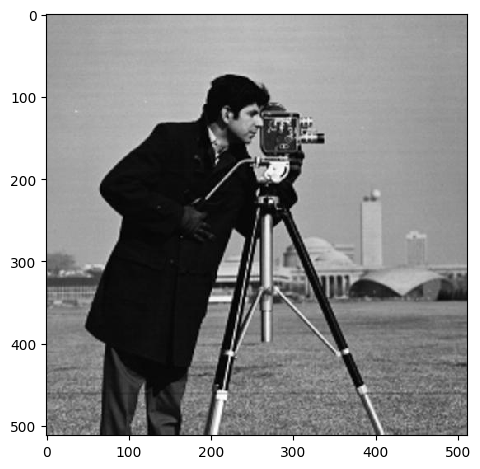

In [8]:
imshow(img_man)
# plt.show()

C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\2398534769.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(img_man)


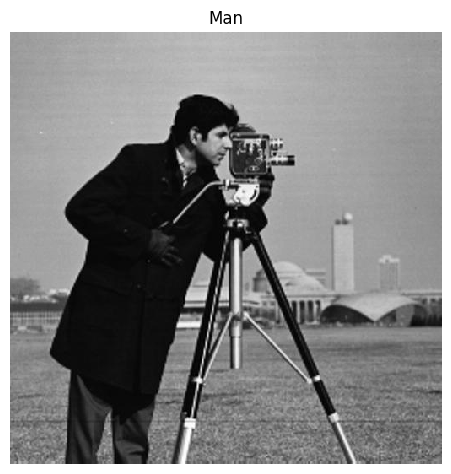

In [9]:
plt.figure(figsize=(5,5))
imshow(img_man)
plt.title("Man")
plt.axis("off")
plt.show()

In [10]:
img_background = imread("Images/background.jpeg")

C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\1176544493.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(img_background)


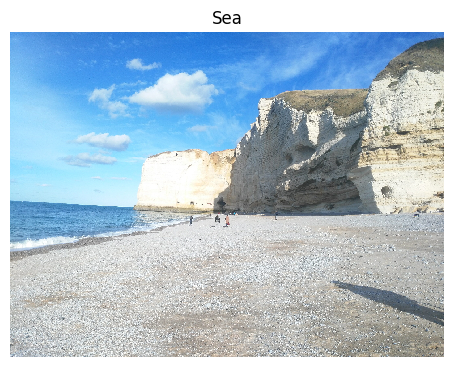

In [11]:
plt.figure(figsize=(5,5))
imshow(img_background)
plt.title("Sea")
plt.axis("off")
plt.show()

In [12]:
# [x_axis, y_axis]
# result : [red, green, blue]
img_background[0,600] 

array([ 37, 121, 217], dtype=uint8)

C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\3353791020.py:8: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(red)
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\3353791020.py:13: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(green)
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\3353791020.py:18: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(blue)


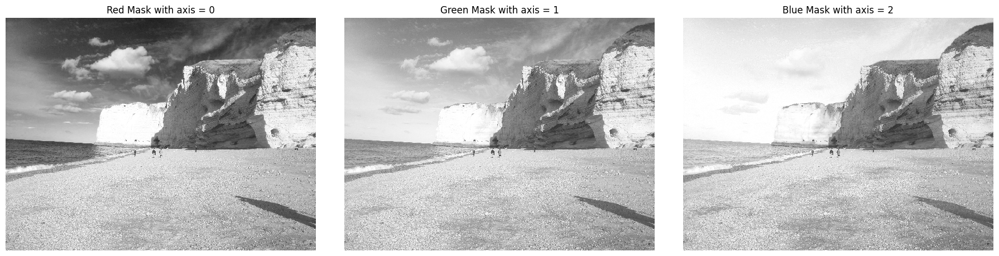

In [13]:
red = img_background[:, :, 0]
green = img_background[:, :, 1]
blue = img_background[:, :, 2]

plt.figure(figsize = (18, 7.5))

plt.subplot(1, 3, 1)
imshow(red)
plt.title('Red Mask with axis = 0')
plt.axis("off")

plt.subplot(1, 3, 2)
imshow(green)
plt.title('Green Mask with axis = 1')
plt.axis("off")

plt.subplot(1, 3, 3)
imshow(blue)
plt.title('Blue Mask with axis = 2')
plt.axis("off")

plt.show()

In [14]:
idk_blue = img_background[:, :, -1]
idk_green = img_background[:, :, -2]
idk_red = img_background[:, :, -3]

colors_dataframe = pd.DataFrame({
"red with axis = 0 & -3 Equal? " : [((idk_red == red).sum()) == red.size],
"green with axis = 1 & -2 Equal? " : [((idk_green == green).sum()) == green.size],
"blue with axis = 2 & -1 Equal? " : [((idk_blue == blue).sum()) == blue.size]
})

colors_table = pd.DataFrame({
    "Condition": [
        "red with axis = 0 & -3 Equal?",
        "green with axis = 1 & -2 Equal?",
        "blue with axis = 2 & -1 Equal?"
    ],
    "Result": [
        np.array_equal(idk_red, red),
        np.array_equal(idk_green, green),
        np.array_equal(idk_blue, blue)
    ]
}, index=None)
colors_table.index = colors_table.index + 1
print(colors_table)

print(colors_table)

                         Condition  Result
1    red with axis = 0 & -3 Equal?    True
2  green with axis = 1 & -2 Equal?    True
3   blue with axis = 2 & -1 Equal?    True
                         Condition  Result
1    red with axis = 0 & -3 Equal?    True
2  green with axis = 1 & -2 Equal?    True
3   blue with axis = 2 & -1 Equal?    True


C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\3907628765.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(idk_red)
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\3907628765.py:8: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(idk_green)
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\3907628765.py:13: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(idk_blue)


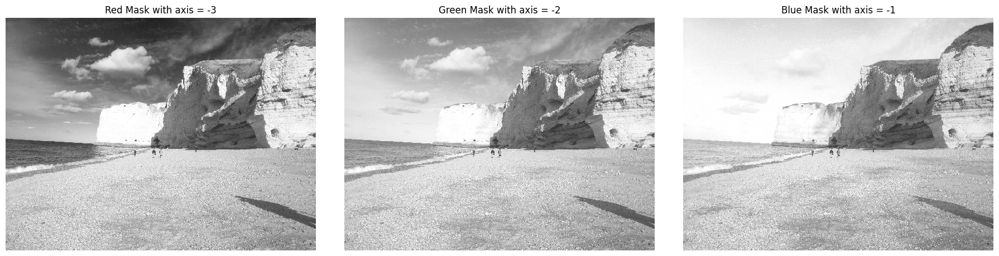

In [15]:
plt.figure(figsize=(18, 7.5))
plt.subplot(1, 3, 1)
imshow(idk_red)
plt.title('Red Mask with axis = -3')
plt.axis("off")

plt.subplot(1, 3, 2)
imshow(idk_green)
plt.title('Green Mask with axis = -2')
plt.axis("off")

plt.subplot(1, 3, 3)
imshow(idk_blue)
plt.title('Blue Mask with axis = -1')
plt.axis("off")

plt.show()

C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\2614144713.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(red, cmap='Reds')  # red
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\2614144713.py:8: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(green, cmap='Greens')
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\2614144713.py:13: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(blue, cmap='Blues')


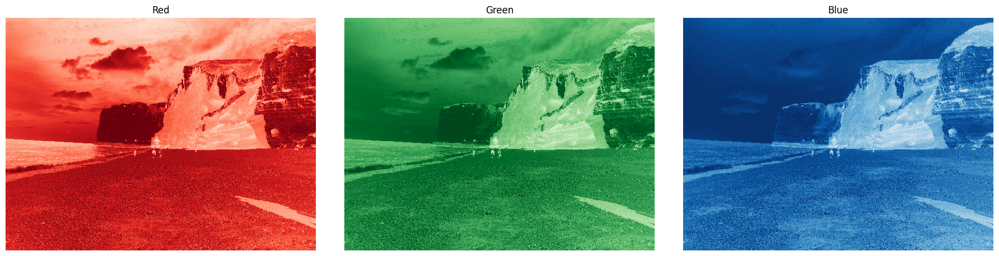

In [16]:
plt.figure(figsize=(18, 7.5))
plt.subplot(1, 3, 1)
imshow(red, cmap='Reds')
plt.title('Red')
plt.axis("off")

plt.subplot(1, 3, 2)
imshow(green, cmap='Greens') 
plt.title('Green')
plt.axis("off")

plt.subplot(1, 3, 3)
imshow(blue, cmap='Blues') 
plt.title('Blue')
plt.axis("off")

plt.show()

In [22]:
green_img = img_background.copy()
green_img[:,:,0] = 0     # set the red channed to 0
green_img[:,:,2] = 0     # set the blue channel to 0


red_img = img_background.copy()
red_img[:,:,1] = 0     # set the green channed to 0
red_img[:,:,2] = 0     # set the blue channel to 0


blue_img = img_background.copy()
blue_img[:,:,0] = 0     # set the red channed to 0
blue_img[:,:,1] = 0     # set the green channel to 0

C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\2157917203.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(red_img)
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\2157917203.py:9: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(green_img)
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\2157917203.py:14: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(blue_img)
c:\Users\RED  LINE\AppData\Local\Programs\Python\Python313\Lib\site-packages\skimage\io\_plugins\matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


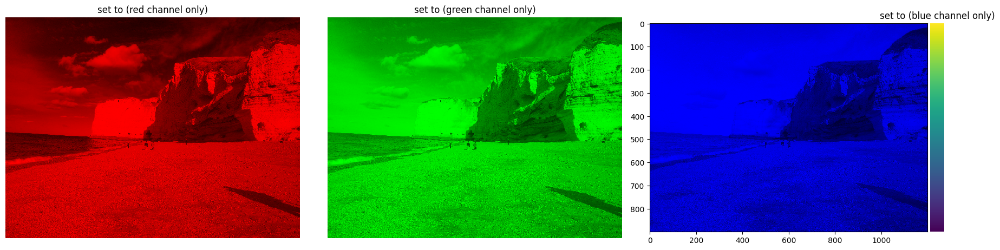

In [26]:
plt.figure(figsize=(18, 7.5))

plt.subplot(1, 3, 1)
imshow(red_img)
plt.title('set to (red channel only)')
plt.axis("off")

plt.subplot(1, 3, 2)
imshow(green_img)
plt.title('set to (green channel only)')
plt.axis("off")

plt.subplot(1, 3, 3)
imshow(blue_img)
plt.title('set to (blue channel only)')
plt.axis("off")

plt.show()

C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\2448654160.py:13: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(img_man)
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\2448654160.py:18: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(translated_img_man_map)
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\2448654160.py:23: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(translated_img_man_inverse)


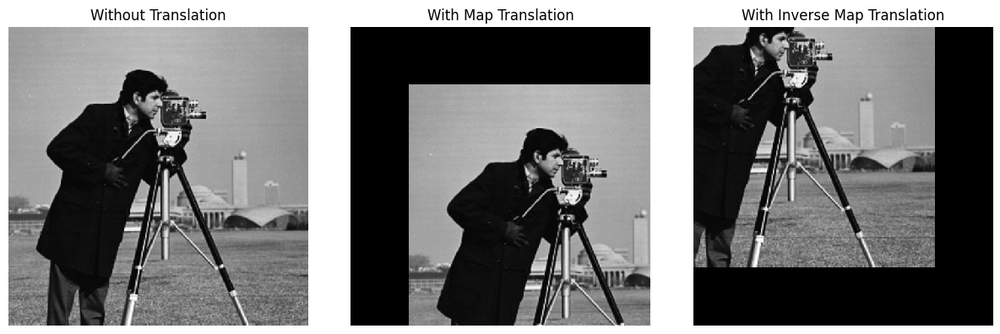

In [17]:
transformer = transform.SimilarityTransform(matrix = np.array(
    [[1, 0, 100],
    [0, 1, 100],
    [0, 0, 1]]
))

translated_img_man_inverse = transform.warp(image = img_man, inverse_map= transformer)
translated_img_man_map = transform.warp(image = img_man, inverse_map = transformer.inverse)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
imshow(img_man)
plt.title('Without Translation')
plt.axis("off")

plt.subplot(1, 3, 2)
imshow(translated_img_man_map)
plt.title('With Map Translation')
plt.axis("off")

plt.subplot(1, 3, 3)
imshow(translated_img_man_inverse)
plt.title('With Inverse Map Translation')
plt.axis("off")

plt.show()

C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\1440809132.py:12: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(img_man)
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\1440809132.py:17: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(scaled_img)
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\1440809132.py:22: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(scaled_img_inverse)


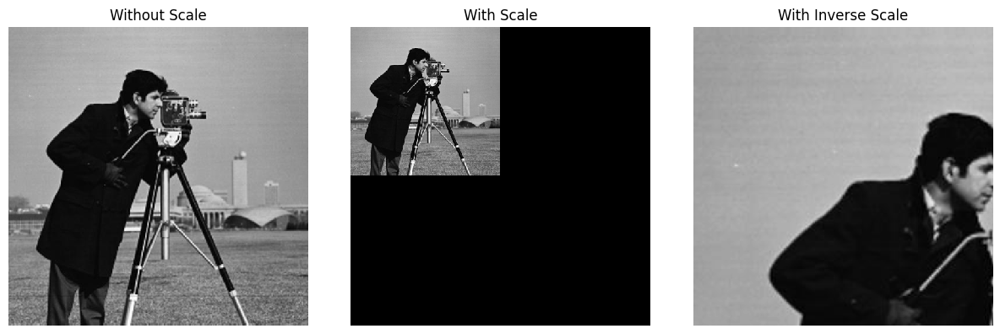

In [34]:
scale_inverse = transform.SimilarityTransform(scale = 2)
scaled_img_inverse = transform.warp(image = img_man , inverse_map = scale_inverse.inverse)

scale_ = transform.SimilarityTransform(scale = 2)
scaled_img = transform.warp(image = img_man, inverse_map=scale_inverse)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 3)

plt.subplot(1, 3, 1)
imshow(img_man)
plt.title('Without Scale')
plt.axis("off")

plt.subplot(1, 3, 2)
imshow(scaled_img)
plt.title('With Scale')
plt.axis("off")

plt.subplot(1, 3, 3)
imshow(scaled_img_inverse)
plt.title('With Inverse Scale')
plt.axis("off")

plt.show()

C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\163460424.py:16: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(img_man)
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\163460424.py:21: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(scale_around_center)
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\163460424.py:26: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(scale_around_center_inverse)


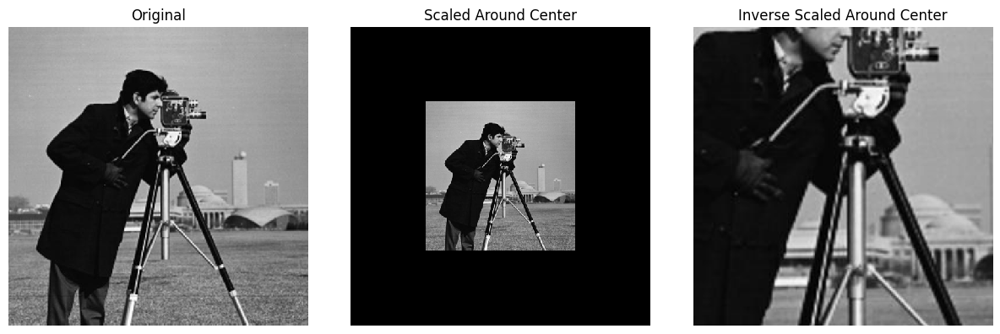

In [ ]:
center = np.array(img_man.shape)//2

# scale around center
shifted = transform.SimilarityTransform(translation= (-center[1] , -center[0] ))

scale = transform.SimilarityTransform(scale=2)

shift_inv = shifted.inverse

trans2 = shifted + scale + shift_inv

scale_around_center = transform.warp(image = img_man , inverse_map = trans2)
scale_around_center_inverse = transform.warp(image = img_man , inverse_map = trans2.inverse)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
imshow(img_man)
plt.title('Original')
plt.axis("off")

plt.subplot(1, 3, 2)
imshow(scale_around_center)
plt.title('Scaled Around Center')
plt.axis("off")

plt.subplot(1, 3, 3)
imshow(scale_around_center_inverse)
plt.title('Inverse Scaled Around Center')
plt.axis("off")

plt.show()

C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\775113981.py:22: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(img_man)
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\775113981.py:27: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(scale_around_center_1)
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\775113981.py:32: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(scale_around_center_2)


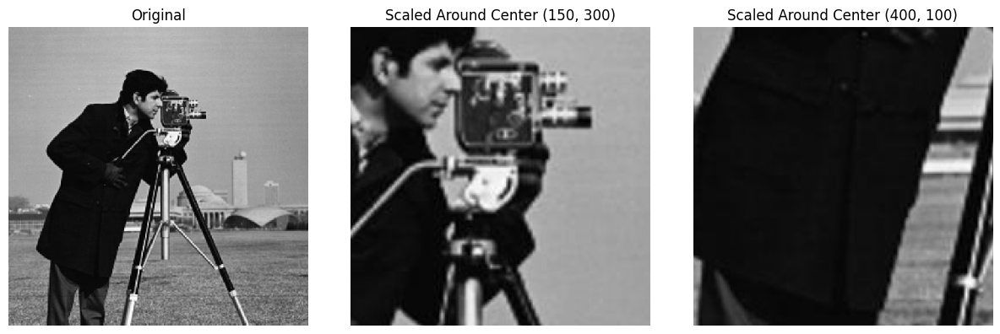

In [76]:
# scale around any point
center1 = [150 ,300]
center2 = [400, 100]

shifted2_1 = transform.SimilarityTransform(translation= (-center1[1] , -center1[0] ))
shifted2_2 = transform.SimilarityTransform(translation= (-center2[1] , -center2[0] ))

scale2 = transform.SimilarityTransform(scale=3)

shift_inv2_1 = shifted2_1.inverse
shift_inv2_2 = shifted2_2.inverse

trans3_1 = shifted2_1 + scale2 + shift_inv2_1
trans3_2 = shifted2_2 + scale2 + shift_inv2_2

scale_around_center_1 = transform.warp(image = img_man , inverse_map = trans3_1.inverse)
scale_around_center_2 = transform.warp(image = img_man , inverse_map = trans3_2.inverse)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
imshow(img_man)
plt.title('Original')
plt.axis("off")

plt.subplot(1, 3, 2)
imshow(scale_around_center_1)
plt.title('Scaled Around Center (150, 300)')
plt.axis("off")

plt.subplot(1, 3, 3)
imshow(scale_around_center_2)
plt.title('Scaled Around Center (400, 100)')
plt.axis("off")

plt.show()

Rotate Around (0,0) Without Translation


C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\2743349305.py:10: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(img_man)
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\2743349305.py:15: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(rotated_img_man_positive1)
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\2743349305.py:20: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(rotated_img_man_negative1)


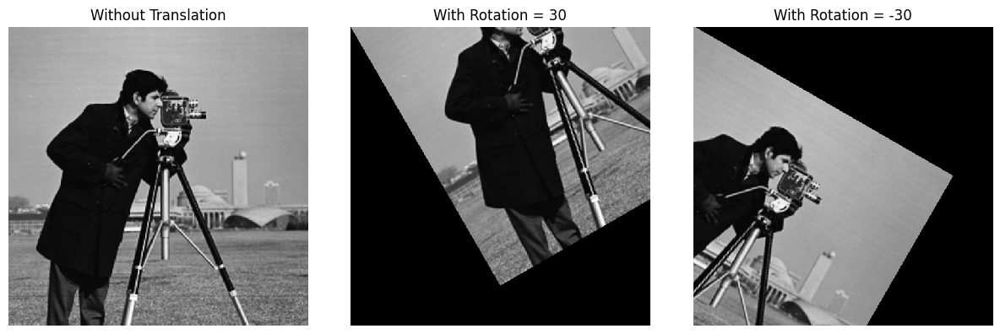

In [18]:
rotater = transform.SimilarityTransform(rotation = np.deg2rad(30))

rotated_img_man_positive1 = transform.warp(image = img_man, inverse_map= rotater)
rotated_img_man_negative1 = transform.warp(image = img_man, inverse_map= rotater.inverse)

print("Rotate Around (0,0) Without Translation")

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
imshow(img_man)
plt.title('Without Translation')
plt.axis("off")

plt.subplot(1, 3, 2)
imshow(rotated_img_man_positive1)
plt.title('With Rotation = 30')
plt.axis("off")

plt.subplot(1, 3, 3)
imshow(rotated_img_man_negative1)
plt.title('With Rotation = -30')
plt.axis("off")

plt.show()

In [42]:
deg_to_rad = np.deg2rad(30)
center = np.array(img_man.shape) // 2
print(f"Center : {center}")

normal_translation = np.array([
    [1,0,-center[1]],
    [0,1,-center[0]],
    [0,0,1]
])

inverse_translation = np.array([
    [1,0,center[1]],
    [0,1,center[0]],
    [0,0,1]
])

rotation = np.array([
    [np.cos(deg_to_rad),  -np.sin(deg_to_rad),  0],
    [np.sin(deg_to_rad),  np.cos(deg_to_rad),  0],
    [0,0,1]
])

rotater_2 = transform.SimilarityTransform(matrix= np.dot(np.dot(inverse_translation, rotation), normal_translation))

rotated_img_man_positive2 = transform.warp(image = img_man, inverse_map= rotater_2)
rotated_img_man_negative2 = transform.warp(image = img_man, inverse_map= rotater_2.inverse)

Center : [256 256]


Rotate Around (0,0) with Translation


C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\2065306428.py:5: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(img_man)
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\2065306428.py:10: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(rotated_img_man_positive2)
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\2065306428.py:15: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(rotated_img_man_negative2)


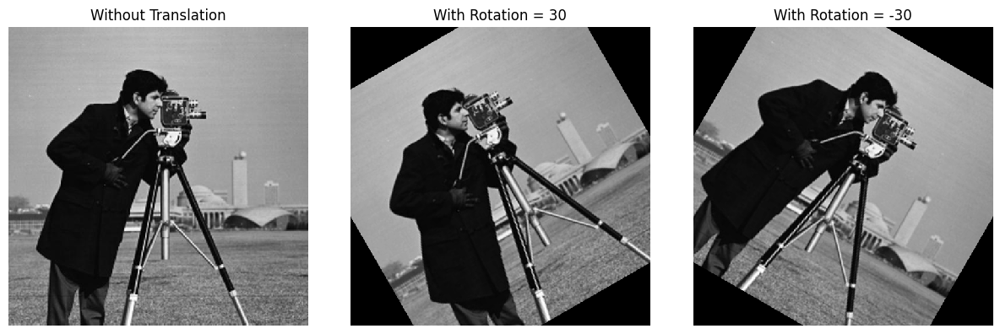

In [43]:
print("Rotate Around (0,0) with Translation")

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
imshow(img_man)
plt.title('Without Translation')
plt.axis("off")

plt.subplot(1, 3, 2)
imshow(rotated_img_man_positive2)
plt.title('With Rotation = 30')
plt.axis("off")

plt.subplot(1, 3, 3)
imshow(rotated_img_man_negative2)
plt.title('With Rotation = -30')
plt.axis("off")

plt.show()

C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\1990672189.py:12: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(img_man)
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\1990672189.py:17: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(rotator2)
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\1990672189.py:22: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(rotator2_inverse_img)


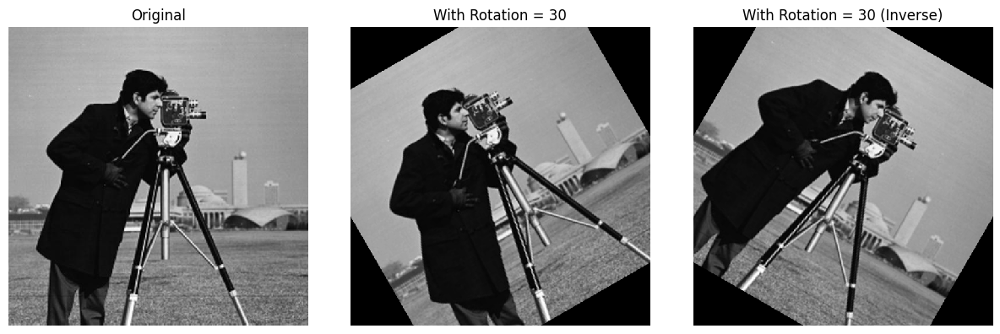

In [51]:
shifted_translation = transform.SimilarityTransform(translation=(-center[1], -center[0]))
rotation =  transform.SimilarityTransform(rotation= deg_to_rad)
inverse_translation = shifted_translation.inverse

whole_process = shifted_translation + rotation + inverse_translation

rotator2 = transform.warp(image = img_man, inverse_map = whole_process)
rotator2_inverse_img = transform.warp(image = img_man, inverse_map = whole_process.inverse)

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
imshow(img_man)
plt.title('Original')
plt.axis("off")

plt.subplot(1, 3, 2)
imshow(rotator2)
plt.title('With Rotation = 30')
plt.axis("off")

plt.subplot(1, 3, 3)
imshow(rotator2_inverse_img)
plt.title('With Rotation = 30 (Inverse)')
plt.axis("off")

plt.show()

C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\3417914171.py:7: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(img_man)
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\3417914171.py:12: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(total_img)
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\3417914171.py:17: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(total_inverse_img)


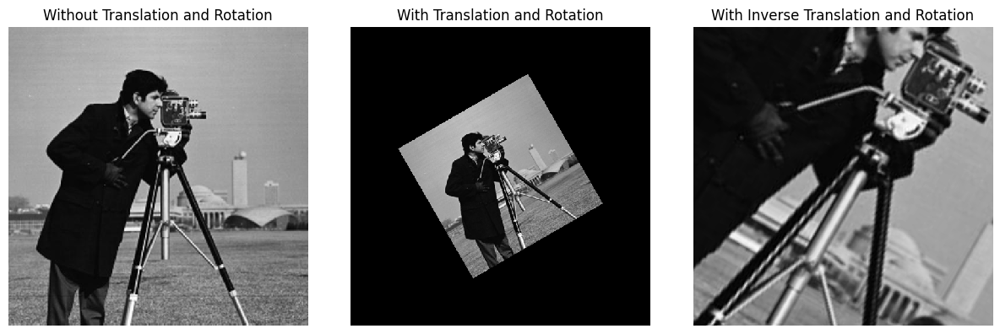

In [47]:
total = trans2 + rotater_2
total_img = transform.warp(image = img_man , inverse_map = total)
total_inverse_img = transform.warp(image = img_man , inverse_map = total.inverse)

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
imshow(img_man)
plt.title('Without Translation and Rotation')
plt.axis("off")

plt.subplot(1, 3, 2)
imshow(total_img)
plt.title('With Translation and Rotation')
plt.axis("off")

plt.subplot(1, 3, 3)
imshow(total_inverse_img)
plt.title('With Inverse Translation and Rotation')
plt.axis("off")

plt.show()

C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\580551416.py:13: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(img_man)
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\580551416.py:18: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(scale_around_center)
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\580551416.py:23: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(scale_around_center_inverse)


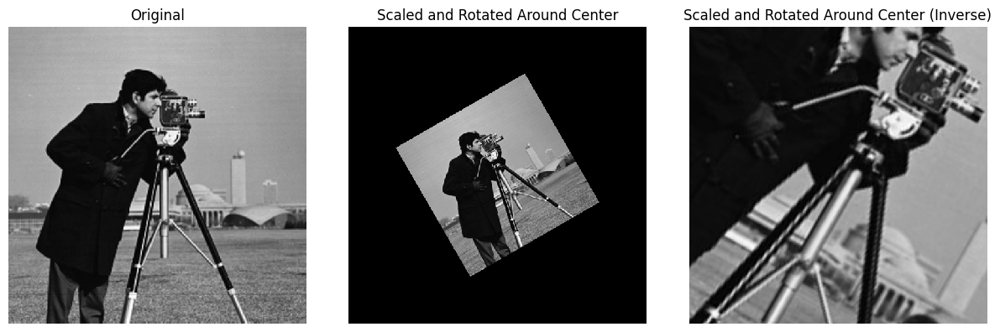

In [50]:
shifted2 = transform.SimilarityTransform(translation= (-center[1] , -center[0] ))
tot2 = transform.SimilarityTransform(scale=2 , rotation = np.deg2rad(30))
shift_inv2 = shifted.inverse

trans4 = shifted2 + tot2 + shift_inv2

scale_around_center = transform.warp(image = img_man , inverse_map = trans4)
scale_around_center_inverse = transform.warp(image = img_man , inverse_map = trans4.inverse)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
imshow(img_man)
plt.title('Original') 
plt.axis("off")

plt.subplot(1, 3, 2)
imshow(scale_around_center)
plt.title('Scaled and Rotated Around Center')
plt.axis("off")

plt.subplot(1, 3, 3)
imshow(scale_around_center_inverse)
plt.title('Scaled and Rotated Around Center (Inverse)')
plt.axis("off")

plt.show()

C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\2078216064.py:11: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(img_man)
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\2078216064.py:16: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(res_1)


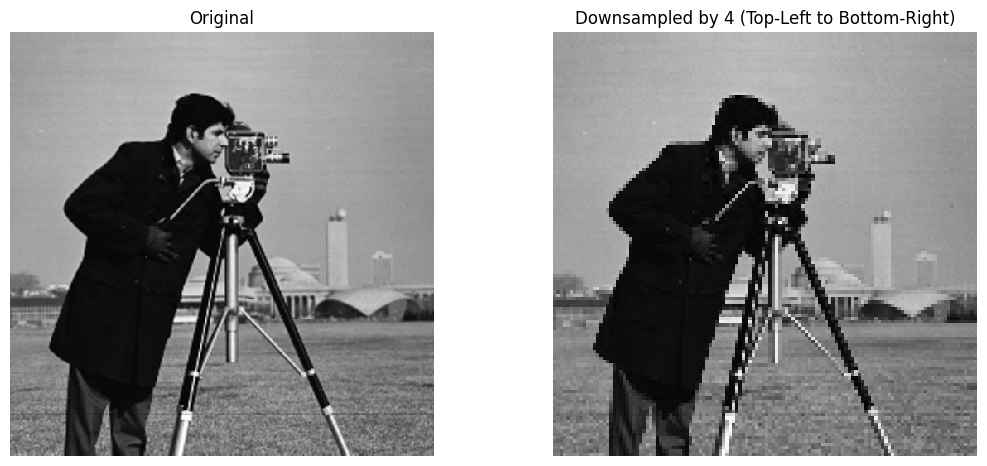

In [55]:
# this code is used to downsample the image by taking every 4th pixel in both dimensions. 
# This effectively reduces the resolution of the image, 
# which can be useful for various applications such as reducing computational load or creating a thumbnail version of the image.

res_1 = img_man[:: 4,   # walk through the pixels by 4
                :: 4]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
imshow(img_man)
plt.title('Original')
plt.axis("off")

plt.subplot(1, 2, 2)
imshow(res_1)
plt.title('Downsampled by 4 (Top-Left to Bottom-Right)')
plt.axis("off")

plt.show()

C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\4117467830.py:10: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(res_with_2)
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\4117467830.py:15: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(res_1)
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\4117467830.py:21: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(res_with_10)


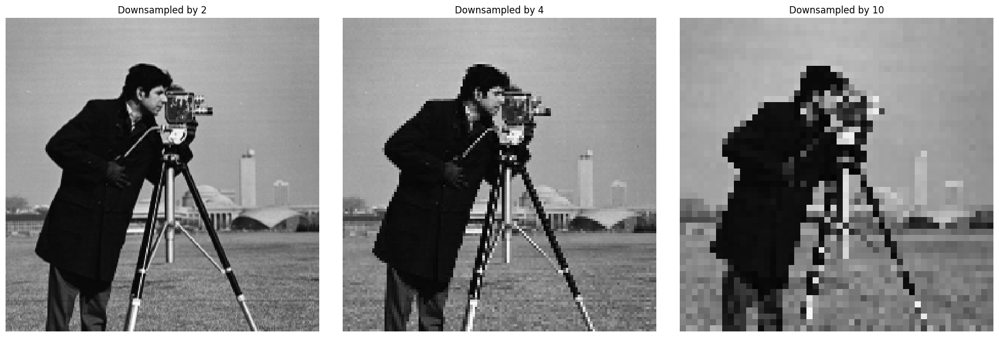

In [ ]:
res_with_2 = img_man[:: 2,  
                :: 2]

res_with_10 = img_man[:: 10,  
                :: 10]

plt.figure(figsize=(18, 7.5))

plt.subplot(1, 3, 1)
imshow(res_with_2)
plt.title('Downsampled by 2')
plt.axis("off")

plt.subplot(1, 3, 2)
imshow(res_1)
plt.title('Downsampled by 4')
plt.axis("off")


plt.subplot(1, 3, 3)
imshow(res_with_10)
plt.title('Downsampled by 10')
plt.axis("off")

plt.show()

C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\1905708225.py:14: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(res_1)
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\1905708225.py:19: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(res_2)
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\1905708225.py:24: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(res_3)
C:\Users\RED  LINE\AppData\Local\Temp\ipykernel_36380\1905708225.py:29: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(res_4)


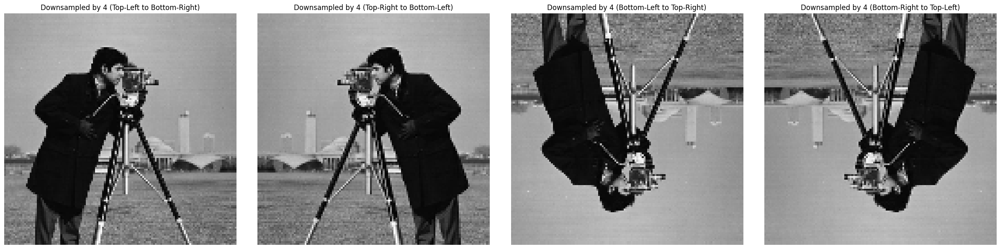

In [ ]:
res_2 = img_man[:: 4,  
                :: -4]

res_3 = img_man[:: -4, 
                :: 4]

res_4 = img_man[:: -4,  
                :: -4]


plt.figure(figsize=(24, 10))

plt.subplot(1, 4, 1)
imshow(res_1)
plt.title('Downsampled by 4 (Top-Left to Bottom-Right)')
plt.axis("off")

plt.subplot(1, 4, 2)
imshow(res_2)
plt.title('Downsampled by 4 (Top-Right to Bottom-Left)')
plt.axis("off")

plt.subplot(1, 4, 3)
imshow(res_3)
plt.title('Downsampled by 4 (Bottom-Left to Top-Right)')
plt.axis("off")

plt.subplot(1, 4, 4)
imshow(res_4)
plt.title('Downsampled by 4 (Bottom-Right to Top-Left)')
plt.axis("off")

plt.show()

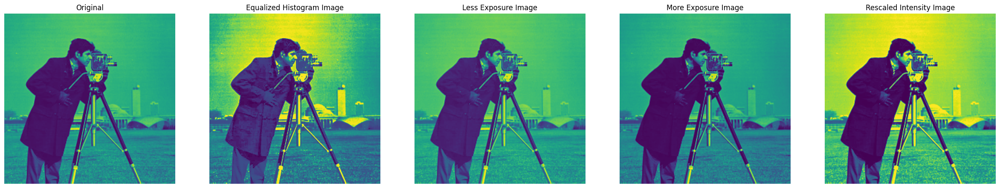

In [62]:
img_exposure = exposure.equalize_hist(img_man)

img_exposure_less_1 = exposure.adjust_gamma(img_man, gamma=0.8)

img_exposure_more_1 = exposure.adjust_gamma(img_man, gamma=1.2)

p2, p98 = np.percentile(img_man, (2, 98))
img_exposure_rescale = exposure.rescale_intensity(img_man, in_range=(p2, p98))

plt.figure(figsize=(30, 12.5))

plt.subplot(1, 5, 1)
plt.imshow(img_man)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 5, 2)
plt.imshow(img_exposure)
plt.title('Equalized Histogram Image')
plt.axis('off')

plt.subplot(1, 5, 3)
plt.imshow(img_exposure_less_1)
plt.title('Less Exposure Image')
plt.axis('off')

plt.subplot(1, 5, 4)
plt.imshow(img_exposure_more_1)
plt.title('More Exposure Image')
plt.axis('off')

plt.subplot(1, 5, 5)
plt.imshow(img_exposure_rescale)
plt.title('Rescaled Intensity Image')
plt.axis('off')

plt.show()

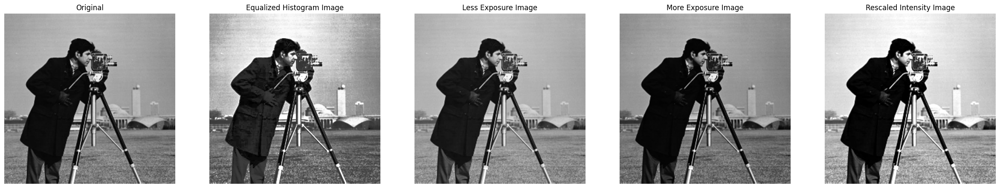

In [64]:
plt.figure(figsize=(30, 12.5))

plt.subplot(1, 5, 1)
plt.imshow(img_man, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 5, 2)
plt.imshow(img_exposure, cmap='gray')
plt.title('Equalized Histogram Image')
plt.axis('off')

plt.subplot(1, 5, 3)
plt.imshow(img_exposure_less_1, cmap='gray')
plt.title('Less Exposure Image')
plt.axis('off')

plt.subplot(1, 5, 4)
plt.imshow(img_exposure_more_1, cmap='gray')
plt.title('More Exposure Image')
plt.axis('off')

plt.subplot(1, 5, 5)
plt.imshow(img_exposure_rescale, cmap='gray')
plt.title('Rescaled Intensity Image')
plt.axis('off')

plt.show()

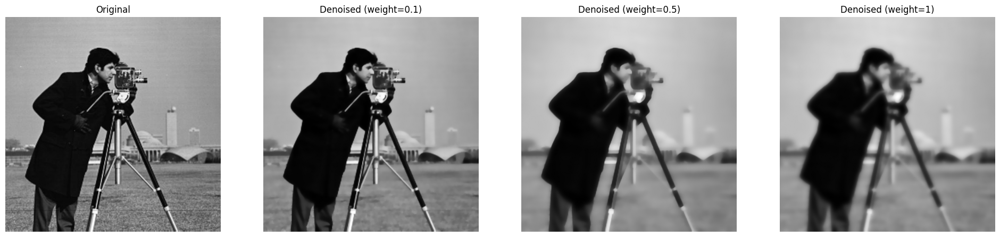

In [65]:
img_denoise_01 = denoise_tv_chambolle(img_man, weight=0.1)
img_denoise_05 = denoise_tv_chambolle(img_man, weight=0.5)
img_denoise_1 = denoise_tv_chambolle(img_man, weight=1)

plt.figure(figsize=(24, 10))

plt.subplot(1, 4, 1)
plt.imshow(img_man, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(img_denoise_01, cmap='gray')
plt.title('Denoised (weight=0.1)')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(img_denoise_05, cmap='gray')
plt.title('Denoised (weight=0.5)')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(img_denoise_1, cmap='gray')
plt.title('Denoised (weight=1)')
plt.axis('off')

plt.show()

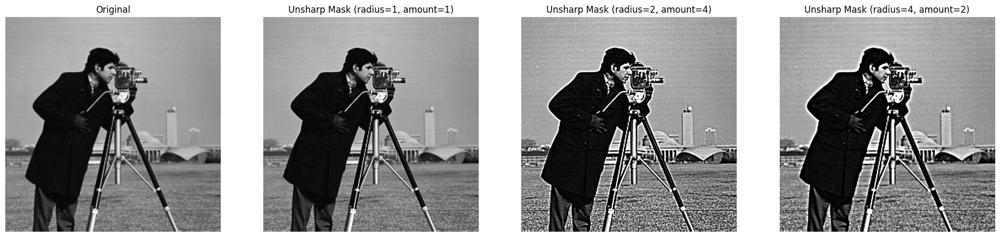

In [67]:
img_unsharp_11 = unsharp_mask(img_man, radius=1, amount=1)
img_unsharp_12 = unsharp_mask(img_man, radius=2, amount=4)
img_unsharp_21 = unsharp_mask(img_man, radius=4, amount=2)

plt.figure(figsize=(24, 10))

plt.subplot(1, 4, 1)
plt.imshow(img_man, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(img_unsharp_11, cmap='gray')
plt.title('Unsharp Mask (radius=1, amount=1)')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(img_unsharp_12, cmap='gray')
plt.title('Unsharp Mask (radius=2, amount=4)')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(img_unsharp_21, cmap='gray')
plt.title('Unsharp Mask (radius=4, amount=2)')
plt.axis('off')

plt.show()

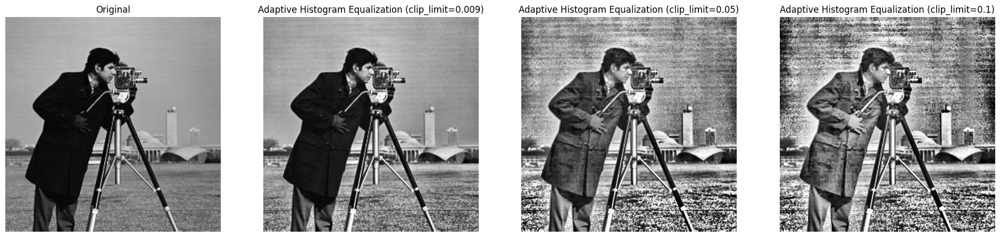

In [73]:
img_adapthist_0009 = exposure.equalize_adapthist(img_man, clip_limit=0.009)
img_adapthist_005 = exposure.equalize_adapthist(img_man, clip_limit=0.05)
img_adapthist_01 = exposure.equalize_adapthist(img_man, clip_limit=0.1)

plt.figure(figsize=(24, 10))

plt.subplot(1, 4, 1)
plt.imshow(img_man, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(img_adapthist_0009, cmap='gray')
plt.title('Adaptive Histogram Equalization (clip_limit=0.009)')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(img_adapthist_005, cmap='gray')
plt.title('Adaptive Histogram Equalization (clip_limit=0.05)')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(img_adapthist_01, cmap='gray')
plt.title('Adaptive Histogram Equalization (clip_limit=0.1)')
plt.axis('off')

plt.show()